# Station-Level Rail Adequacy Score Analysis
This notebook builds a station-level railway adequacy dataset for India. It loads railway station, schedule, train route, district boundary, and SHRUG district-level data. Stations are mapped to Census 2011 districts using coordinates and a district shapefile. A Rail Adequacy Score (RAS) is computed for each station, then averaged by district for mapping. The notebook also fits an OLS regression model and compares it with a Random Forest sensitivity check.

## How to Run
Run the notebook from top to bottom. The following input files must be in the same folder as this notebook:

- stations.csv
- schedules.csv
- trains.csv
- shrug_district_df_clean.csv
- 2011_Dist.shp
- 2011_Dist.shx
- 2011_Dist.dbf
- 2011_Dist.prj

Required packages:

- pandas
- numpy
- geopandas
- matplotlib
- seaborn
- scikit-learn
- statsmodels

A fixed random seed of 100 is used for reproducibility.

## 1. Imports and Setup

In [91]:
import pandas as pd
import numpy as np
import geopandas as gpd
import ast
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
import os
import json

## Optional JSON to CSV Conversion

The shared railway data are stored as JSON files in the repository. This optional step converts `stations.json`, `trains.json`, and `schedules.json` to CSV only if the CSV files are not already available.

In [102]:
# Optional preprocessing: convert railway JSON files to CSV if CSV files are not already available

rail_path = "../common_dataset/data/rail"
stations_json = os.path.join(rail_path, "stations.json")
trains_json = os.path.join(rail_path, "trains.json")
schedules_json = os.path.join(rail_path, "schedules.json")

stations_csv = "stations.csv"
trains_csv = "trains.csv"
schedules_csv = "schedules.csv"

print("Stations JSON found:", os.path.exists(stations_json))
print("Trains JSON found:", os.path.exists(trains_json))
print("Schedules JSON found:", os.path.exists(schedules_json))

if not os.path.exists(stations_csv) and os.path.exists(stations_json):
    with open(stations_json, "r", encoding="utf-8") as f:
        stations_data = json.load(f)

    stations_rows = []
    for feature in stations_data["features"]:
        props = feature.get("properties", {})
        geometry = feature.get("geometry", {})
        stations_rows.append({
            "state": props.get("state"),
            "code": props.get("code"),
            "name": props.get("name"),
            "zone": props.get("zone"),
            "address": props.get("address"),
            "geometry_type": geometry.get("type") if geometry else None,
            "coordinates": geometry.get("coordinates") if geometry else None
        })

    pd.DataFrame(stations_rows).to_csv(stations_csv, index=False)

if not os.path.exists(trains_csv) and os.path.exists(trains_json):
    with open(trains_json, "r", encoding="utf-8") as f:
        trains_data = json.load(f)

    trains_rows = []
    for feature in trains_data["features"]:
        props = feature.get("properties", {})
        geometry = feature.get("geometry", {})
        trains_rows.append({
            "third_ac": props.get("third_ac"),
            "arrival": props.get("arrival"),
            "from_station_code": props.get("from_station_code"),
            "name": props.get("name"),
            "zone": props.get("zone"),
            "chair_car": props.get("chair_car"),
            "first_class": props.get("first_class"),
            "duration_m": props.get("duration_m"),
            "sleeper": props.get("sleeper"),
            "from_station_name": props.get("from_station_name"),
            "number": props.get("number"),
            "departure": props.get("departure"),
            "return_train": props.get("return_train"),
            "to_station_code": props.get("to_station_code"),
            "second_ac": props.get("second_ac"),
            "classes": props.get("classes"),
            "to_station_name": props.get("to_station_name"),
            "duration_h": props.get("duration_h"),
            "type": props.get("type"),
            "first_ac": props.get("first_ac"),
            "distance": props.get("distance"),
            "geometry_type": geometry.get("type") if geometry else None,
            "coordinates": geometry.get("coordinates") if geometry else None
        })

    pd.DataFrame(trains_rows).to_csv(trains_csv, index=False)

if not os.path.exists(schedules_csv) and os.path.exists(schedules_json):
    with open(schedules_json, "r", encoding="utf-8") as f:
        schedules_data = json.load(f)

    pd.DataFrame(schedules_data).to_csv(schedules_csv, index=False)

Stations JSON found: False
Trains JSON found: False
Schedules JSON found: False


## 2. Data Loading and Cleaning
This section loads the railway, train schedule, train route, district boundary, and SHRUG district-level datasets. Station codes, train numbers, and district/state names are standardized to improve matching across datasets.

In [6]:
np.random.seed(100)

#Loading datasets
stations = pd.read_csv("stations.csv", low_memory = False)
schedules = pd.read_csv("schedules.csv", low_memory= False)
trains = pd.read_csv("trains.csv", low_memory = False)
districts = gpd.read_file("2011_Dist.shp")
shrug_district_df = pd.read_csv("shrug_district_df_clean.csv")

districts = districts.rename(columns={"ST_NM": "State","DISTRICT": "District"})
stations["code"] = stations["code"].astype(str).str.strip().str.upper()
schedules["station_code"] = schedules["station_code"].astype(str).str.strip().str.upper()
schedules["train_number"] = schedules["train_number"].astype(str).str.strip()
trains["number"] = trains["number"].astype(str).str.strip()
trains["from_station_code"] = trains["from_station_code"].astype(str).str.strip().str.upper()
trains["to_station_code"] = trains["to_station_code"].astype(str).str.strip().str.upper()
districts["State"] = districts["State"].astype(str).str.strip()
districts["District"] = districts["District"].astype(str).str.strip()
shrug_district_df["State"] = shrug_district_df["State"].astype(str).str.strip()
shrug_district_df["District"] = shrug_district_df["District"].astype(str).str.strip()
stations = stations[~stations["code"].str.contains(r"^XX-|^YY-", na=False)].copy()

print("Stations:", stations.shape)
print("Schedules:", schedules.shape)
print("Trains:", trains.shape)
print("Districts:", districts.shape)
print("SHRUG:", shrug_district_df.shape)

Stations: (8967, 7)
Schedules: (417080, 8)
Trains: (5208, 23)
Districts: (641, 6)
SHRUG: (635, 11)


## 3. Mapping Stations to Districts
Station coordinates are converted into geographic points and spatially joined with the Census 2011 district shapefile. This assigns each station to a district.

In [10]:
#Mapping stations to districts using coordinates
#Converting station coordinate strings into longitude and latitude values
stations2 = stations.copy()
stations2["coordinates"] = stations2["coordinates"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
stations2["lon"] = stations2["coordinates"].apply(lambda x: x[0] if isinstance(x, list) else np.nan)
stations2["lat"] = stations2["coordinates"].apply(lambda x: x[1] if isinstance(x, list) else np.nan)
stations2 = stations2.dropna(subset=["lon", "lat"]).copy()
stations_gdf = gpd.GeoDataFrame(stations2,geometry=gpd.points_from_xy(stations2["lon"], stations2["lat"]),crs="EPSG:4326")
districts_gdf = districts.copy()
if districts_gdf.crs is None:
    districts_gdf = districts_gdf.set_crs("EPSG:4326")

districts_gdf = districts_gdf.to_crs("EPSG:4326")
stations_with_district = gpd.sjoin(stations_gdf,districts_gdf[["State", "District", "geometry"]], how="left",predicate="within")

print("Stations with coordinates:", stations_gdf.shape[0])
print("Stations matched to districts:", stations_with_district["District"].notna().sum())
print("Unique districts from spatial join:", stations_with_district[["State", "District"]].dropna().drop_duplicates().shape[0])

Stations with coordinates: 8697
Stations matched to districts: 8691
Unique districts from spatial join: 516


## 4. Station-Level Railway Feature Engineering
This section creates station-level railway service variables from schedules and train routes, including total schedule rows, unique trains serving each station, and route connectivity.

In [14]:
#Creating station-level railway variables

station_schedule_table = schedules.groupby("station_code").agg(total_schedule_rows=("station_code", "size"), 
                                                               unique_trains_serving_station=("train_number", "nunique")).reset_index()

outbound_routes = trains.groupby("from_station_code").agg(outbound_routes=("number", "nunique")).reset_index().rename(columns={"from_station_code": "station_code"})
inbound_routes = trains.groupby("to_station_code").agg(inbound_routes=("number", "nunique")
).reset_index().rename(columns={"to_station_code": "station_code"})

route_connectivity = outbound_routes.merge(inbound_routes, on="station_code", how="outer").fillna(0)
route_connectivity["route_connectivity"] = (route_connectivity["outbound_routes"] + route_connectivity["inbound_routes"])
station_schedule_table = station_schedule_table.merge(route_connectivity,on="station_code", how="left")
station_schedule_table[["outbound_routes", "inbound_routes", "route_connectivity"]] = (
    station_schedule_table[["outbound_routes", "inbound_routes", "route_connectivity"]].fillna(0))

print(station_schedule_table.shape)
station_schedule_table.head()

(8539, 6)


,station_code,total_schedule_rows,unique_trains_serving_station,outbound_routes,inbound_routes,route_connectivity
0,AA,22,22,0.0,0.0,0.0
1,AABH,32,32,0.0,0.0,0.0
2,AAG,73,73,0.0,0.0,0.0
3,AAH,8,8,0.0,0.0,0.0
4,AAK,19,17,0.0,0.0,0.0


## 5. Data Integration with SHRUG Predictors

The station-level railway dataset is merged with district-level SHRUG predictors using State and District.

In [16]:
#Merging station service with district mapping
# Spatially joining station points to district polygons

station_district_map = stations_with_district[["code", "name", "State", "District"]].dropna(subset=["State", "District"]).drop_duplicates()
station_final_spatial = station_schedule_table.merge(station_district_map,left_on="station_code", right_on="code", how="left")

print("Station final before SHRUG:", station_final_spatial.shape)
print("Missing district:", station_final_spatial["District"].isna().sum())
print("Districts covered:", station_final_spatial[["State", "District"]].dropna().drop_duplicates().shape[0])

Station final before SHRUG: (8539, 10)
Missing district: 297
Districts covered: 514


In [19]:
#Merging SHRUG/Census predictors
station_final_spatial = station_final_spatial.merge(shrug_district_df, on=["State", "District"], how="left")

print("Station final after SHRUG:", station_final_spatial.shape)
print("Missing SHRUG population:", station_final_spatial["shrug_population"].isna().sum())
print("Districts covered:", station_final_spatial[["State", "District"]].dropna().drop_duplicates().shape[0])

station_final_spatial.to_csv("station_final_spatial.csv", index=False)

Station final after SHRUG: (8539, 19)
Missing SHRUG population: 758
Districts covered: 514


## 6. Rail Adequacy Score Calculation

RAS is computed at the station level using normalized railway supply indicators and demand indicators. Supply includes schedule frequency, unique trains, and route connectivity. Demand includes population and population density.

In [23]:
#Computing station-level RAS
# Replacing zero area with NaN to avoid division by zero
# Min-max scaling on each variable on a 0 to 1 scale before combining them
# Here, RAS measures railway supply relative to demand; higher values mean better adequacy

df = station_final_spatial.copy()

df["shrug_area"] = df["shrug_area"].replace(0, np.nan)
df["population_density"] = df["shrug_population"] / df["shrug_area"]

selected_cols = ["State","District","station_code", "total_schedule_rows","unique_trains_serving_station","route_connectivity","shrug_population",
               "shrug_area", "population_density"]

ras_data = df.dropna(subset = selected_cols).copy()

def minmax(x):
    if x.max() == x.min():
        return x * 0
    return (x - x.min()) / (x.max() - x.min())

ras_data["schedule_index"] = minmax(ras_data["total_schedule_rows"])
ras_data["train_index"] = minmax(ras_data["unique_trains_serving_station"])
ras_data["route_connectivity_index"] = minmax(ras_data["route_connectivity"])
ras_data["population_index"] = minmax(ras_data["shrug_population"])
ras_data["density_index"] = minmax(ras_data["population_density"])
ras_data["supply_index"] = (0.4 * ras_data["schedule_index"] + 0.4 * ras_data["train_index"] + 0.2 * ras_data["route_connectivity_index"])
ras_data["demand_index"] = (0.5 * ras_data["population_index"] + 0.5 * ras_data["density_index"])
ras_data["RAS"] = ras_data["supply_index"] / (ras_data["supply_index"] + ras_data["demand_index"])
ras_data["RAS"] = ras_data["RAS"].fillna(0)

print("Rows for RAS:", ras_data.shape[0])
print("Districts covered:", ras_data[["State", "District"]].drop_duplicates().shape[0])
print(ras_data["RAS"].describe())

ras_data.to_csv("station_level_RAS.csv", index=False)

Rows for RAS: 7778
Districts covered: 479
count    7778.000000
mean        0.426140
std         0.252701
min         0.000000
25%         0.205020
50%         0.429021
75%         0.634581
max         0.935194
Name: RAS, dtype: float64


In [26]:
#Calculating average RAS by district

district_ras = ras_data.groupby(["State", "District"], as_index=False).agg(avg_RAS=("RAS", "mean"), station_count=("station_code", "nunique"),
    avg_supply_index=("supply_index", "mean"),avg_demand_index=("demand_index", "mean"), total_schedule_rows=("total_schedule_rows", "sum"),
    avg_route_connectivity=("route_connectivity", "mean"))

print(district_ras.shape)
district_ras.head()

district_ras.to_csv("district_average_RAS.csv", index=False)

(479, 8)


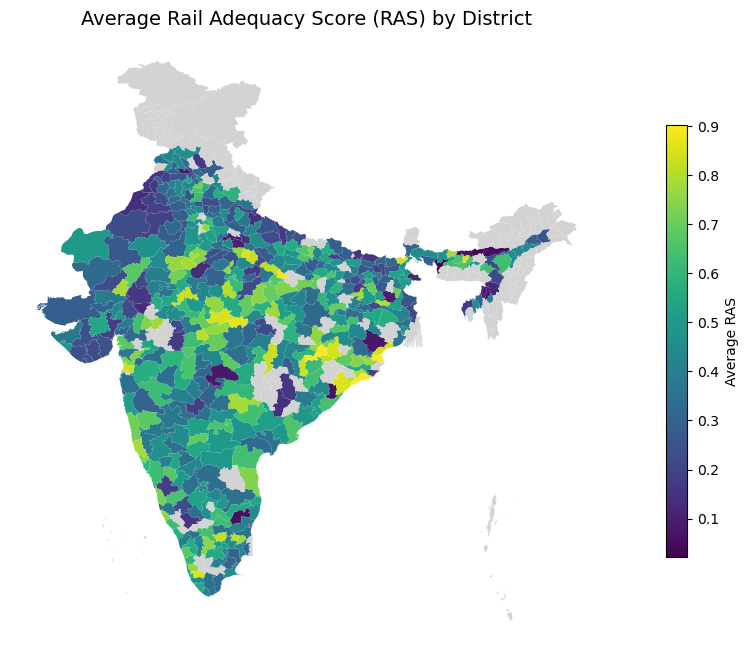

In [29]:
#Creating choropleth map

district_map = districts.merge(district_ras, on=["State", "District"], how="left")
ax = district_map.plot(column="avg_RAS", legend=True, figsize=(16, 8), missing_kwds={"color": "lightgrey", "label": "No data"},
                      legend_kwds={"label": "Average RAS", "shrink": 0.7})
ax.set_title("Average Rail Adequacy Score (RAS) by District", fontsize=14)
ax.axis("off")
plt.savefig("average_RAS_choropleth.png", dpi = 300, bbox_inches = "tight")
plt.show()

## 7. Exploratory Data Analysis and Modeling

This section uses station-level RAS as the response variable. It includes summary statistics, correlations, outlier screening, VIF, OLS regression, model evaluation, cross-validation, and a Random Forest sensitivity check.

In [33]:
#Creating analysis dataset
np.random.seed(100)

analysis_data = ras_data.copy()
print(analysis_data.shape)
print(analysis_data["RAS"].describe())

(7778, 28)
count    7778.000000
mean        0.426140
std         0.252701
min         0.000000
25%         0.205020
50%         0.429021
75%         0.634581
max         0.935194
Name: RAS, dtype: float64


In [35]:
analysis_data.head()

,station_code,total_schedule_rows,unique_trains_serving_station,outbound_routes,inbound_routes,route_connectivity,code,name,State,District,...,shrug_city5_dist,population_density,schedule_index,train_index,route_connectivity_index,population_index,density_index,supply_index,demand_index,RAS
0,AA,22,22,0.0,0.0,0.0,AA,ATARIA,Uttar Pradesh,Sitapur,...,4.0,4975.944502,0.067524,0.070707,0.0,0.055490,0.186321,0.055292,0.120906,0.313808
2,AAG,73,73,0.0,0.0,0.0,AAG,ANGAR,Maharashtra,Solapur,...,38.0,3853.289818,0.231511,0.242424,0.0,0.148410,0.143985,0.189574,0.146198,0.564592
3,AAH,8,8,0.0,0.0,0.0,AAH,ITEHAR,Madhya Pradesh,Bhind,...,22.0,1906.809373,0.022508,0.023569,0.0,0.045018,0.070582,0.018431,0.057800,0.241777
4,AAK,19,17,0.0,0.0,0.0,AAK,ANKAI KILA,Maharashtra,Nashik,...,11.0,4013.184283,0.057878,0.053872,0.0,0.276641,0.150015,0.044700,0.213328,0.173237
5,AAL,40,40,0.0,0.0,0.0,AAL,AMLAI,Madhya Pradesh,Shahdol,...,170.0,1452.310725,0.125402,0.131313,0.0,0.019977,0.053442,0.102686,0.036710,0.736651


In [38]:
# Selected predictors include railway service, route connectivity, and district-level socioeconomic variables used to explain RAS.

model_vars = ["total_schedule_rows", "route_connectivity", "shrug_population","shrug_area", "shrug_population_density",
    "shrug_rail_dist", "shrug_city_dist","shrug_city5_dist"]
model_data = analysis_data[["RAS"] + model_vars].dropna().copy()
model_data.head()

,RAS,total_schedule_rows,route_connectivity,shrug_population,shrug_area,shrug_population_density,shrug_rail_dist,shrug_city_dist,shrug_city5_dist
0,0.313808,22,0.0,530784.0,106.67,4975.944502,0.0,4.0,4.0
2,0.564592,73,0.0,1399091.0,363.09,3853.289818,0.0,35.0,38.0
3,0.241777,8,0.0,432922.0,227.04,1906.809373,0.0,0.0,22.0
4,0.173237,19,0.0,2597373.0,647.21,4013.184283,0.0,2.0,11.0
5,0.736651,40,0.0,198923.0,136.97,1452.310725,0.0,55.0,170.0


In [41]:
#Performing exploratory data analysis
summary_table = model_data.describe().T
summary_table = summary_table[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
summary_table.to_csv("summary_statistics_table.csv")
summary_table

,count,mean,std,min,25%,50%,75%,max
RAS,7778.0,4.261400e-01,2.527010e-01,0.000000,0.20502,0.429021,6.345807e-01,9.351938e-01
total_schedule_rows,7778.0,5.041656e+01,5.142001e+01,1.000000,10.00000,30.000000,7.700000e+01,3.120000e+02
route_connectivity,7778.0,1.173181e+00,7.168697e+00,0.000000,0.00000,0.000000,0.000000e+00,2.630000e+02
shrug_population,7778.0,1.000423e+06,1.269906e+06,12242.000000,289434.00000,567599.500000,1.207826e+06,9.356962e+06
shrug_area,7778.0,2.978304e+02,4.612526e+02,5.860000,83.96000,187.270000,3.537000e+02,7.200552e+03
shrug_population_density,7778.0,4.087450e+03,2.921518e+03,35.144389,2323.19762,3459.203085,5.155885e+03,2.655275e+04
shrug_rail_dist,7778.0,3.000771e-01,3.560145e+00,0.000000,0.00000,0.000000,0.000000e+00,2.160000e+02
shrug_city_dist,7778.0,1.571214e+01,2.815549e+01,0.000000,0.00000,4.000000,2.000000e+01,2.240000e+02
shrug_city5_dist,7778.0,6.572924e+01,7.717919e+01,0.000000,7.00000,46.000000,9.800000e+01,5.550000e+02


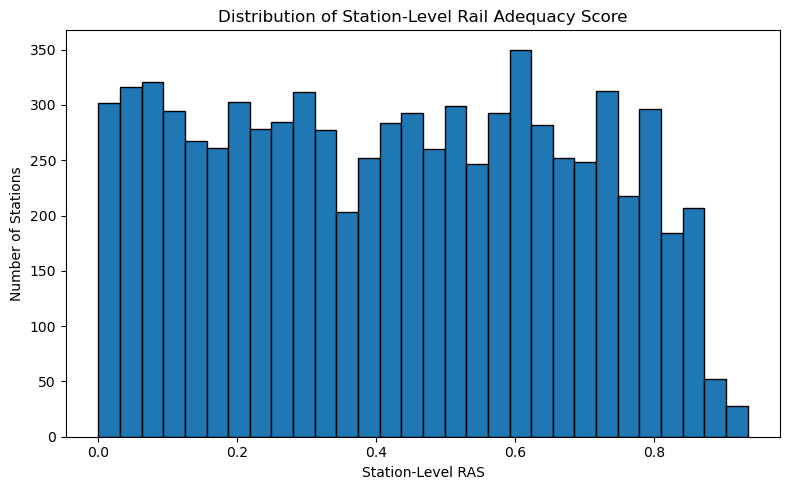

In [44]:
#Histogram plot of station-level RAS
plt.figure(figsize=(8, 5))
plt.hist(model_data["RAS"], bins = 30, edgecolor="black")
plt.xlabel("Station-Level RAS")
plt.ylabel("Number of Stations")
plt.title("Distribution of Station-Level Rail Adequacy Score")
plt.tight_layout()
plt.savefig("ras_histogram.png", dpi = 300, bbox_inches="tight")
plt.show()

In [47]:
#Examining correlations
corr_table = model_data.corr()
corr_table

,RAS,total_schedule_rows,route_connectivity,shrug_population,shrug_area,shrug_population_density,shrug_rail_dist,shrug_city_dist,shrug_city5_dist
RAS,1.000000,0.757018,0.102430,-0.142388,0.041444,-0.258108,0.028984,0.067602,0.002903
total_schedule_rows,0.757018,1.000000,0.176228,0.259717,0.084541,0.124112,-0.042666,-0.117421,-0.205938
route_connectivity,0.102430,0.176228,1.000000,0.076360,0.016624,0.090315,-0.006150,-0.030534,-0.034411
shrug_population,-0.142388,0.259717,0.076360,1.000000,0.322493,0.482064,-0.047773,-0.229502,-0.366228
shrug_area,0.041444,0.084541,0.016624,0.322493,1.000000,-0.161011,-0.000427,-0.057415,-0.151165
shrug_population_density,-0.258108,0.124112,0.090315,0.482064,-0.161011,1.000000,-0.043222,-0.164025,-0.204115
shrug_rail_dist,0.028984,-0.042666,-0.006150,-0.047773,-0.000427,-0.043222,1.000000,0.105602,0.122707
shrug_city_dist,0.067602,-0.117421,-0.030534,-0.229502,-0.057415,-0.164025,0.105602,1.000000,0.392129
shrug_city5_dist,0.002903,-0.205938,-0.034411,-0.366228,-0.151165,-0.204115,0.122707,0.392129,1.000000


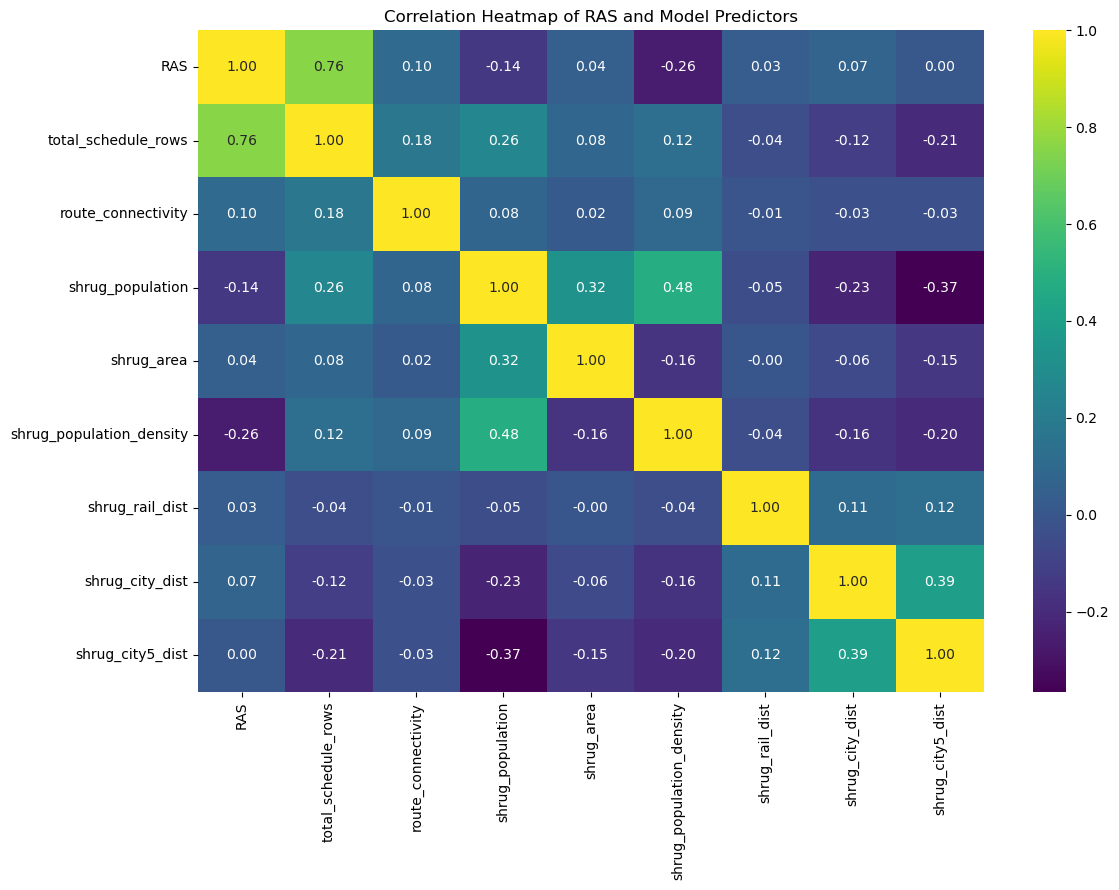

In [50]:
#Correlation heatmap of RAS and model predictors

plt.figure(figsize=(12, 9))
sns.heatmap(corr_table, annot=True, fmt=".2f", cmap="viridis")
plt.title("Correlation Heatmap of RAS and Model Predictors")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi = 300, bbox_inches="tight")
plt.show()

In [53]:
#Performing VIF

X_vif = model_data[model_vars].copy()
X_vif = sm.add_constant(X_vif)
vif_table = pd.DataFrame()
vif_table["Variable"] = X_vif.columns
vif_table["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_table

,Variable,VIF
0,const,6.734374
1,total_schedule_rows,1.119673
2,route_connectivity,1.037737
3,shrug_population,1.834548
4,shrug_area,1.311081
5,shrug_population_density,1.538694
6,shrug_rail_dist,1.020056
7,shrug_city_dist,1.202588
8,shrug_city5_dist,1.335917


In [56]:
#Examining outliers
def iqr_outliers(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return data[(data[col] < lower) | (data[col] > upper)]

for col in model_data.columns:
    outliers = iqr_outliers(model_data, col)
    print(col, outliers.shape[0])

print("Outliers were screened using the IQR rule. They were not removed because high railway service counts could represent real major stations rather than data errors.")

RAS 0
total_schedule_rows 295
route_connectivity 685
shrug_population 597
shrug_area 623
shrug_population_density 213
shrug_rail_dist 314
shrug_city_dist 607
shrug_city5_dist 319
Outliers were screened using the IQR rule. They were not removed because high railway service counts could represent real major stations rather than data errors.


In [59]:
#Train/test split

X = model_data[model_vars]  #predictors
y = model_data["RAS"]  #response variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 100)

print(X_train.shape)
print(X_test.shape)

(6222, 8)
(1556, 8)


In [62]:
#Fitting least squares linear regression model with station-level RAS as the response variable
X_train_sm = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    RAS   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.751
Method:                 Least Squares   F-statistic:                     2353.
Date:                Sun, 26 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:04:42   Log-Likelihood:                 4059.2
No. Observations:                6222   AIC:                            -8100.
Df Residuals:                    6213   BIC:                            -8040.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

The OLS model is used as the main statistical model because it provides interpretable coefficients, p-values, an overall F-test, and diagnostic checks. RAS is the response variable, and the selected railway and socioeconomic variables are predictors.

In [67]:
#Evaluating linear regression model
X_test_sm = sm.add_constant(X_test)
y_pred = model.predict(X_test_sm)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("Test R-squared:", r2)

RMSE: 0.1315362855432701
MAE: 0.10194970955123038
Test R-squared: 0.7265698317806609


In [71]:
#performing Cross validation
lm = LinearRegression()
kf = KFold(n_splits = 5, shuffle =True, random_state = 100)
cv_scores = cross_val_score(lm, X, y, cv=kf, scoring="r2")

print("CV R-squared scores:", cv_scores)
print("Mean CV R-squared:", cv_scores.mean())

CV R-squared scores: [0.72656983 0.74763478 0.75636046 0.74522228 0.74726083]
Mean CV R-squared: 0.7446096365163399


In [74]:
#Computing fitted values and residuals from the OLS model for diagnostic plots
fitted = model.fittedvalues
residuals = model.resid

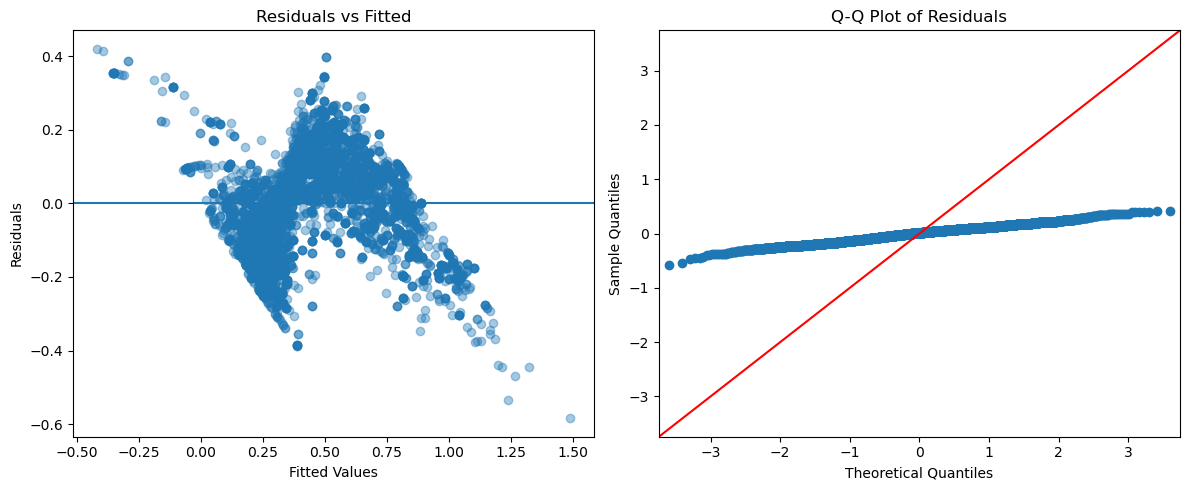

In [76]:
#Residual plots and QQ plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(fitted, residuals, alpha=0.4)
axes[0].axhline(0)
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

sm.qqplot(residuals, line = "45", ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.savefig("ols_diagnostic_plots.png", dpi = 300, bbox_inches="tight")
plt.show()

The residual plots show that the OLS assumptions are not perfectly satisfied. The residuals vs fitted plot shows some pattern, and the Q-Q plot shows deviations from normality. This is expected because RAS is bounded between 0 and 1. Therefore, OLS is used as an interpretable baseline model, while Random Forest is included as a nonlinear sensitivity check.

In [80]:
# Random Forest sensitivity check
# This model is used for comparison since it can capture nonlinear patterns.
# It is not treated as the main statistical model because some predictors are related to the RAS formula.

rf = RandomForestRegressor(n_estimators=300,random_state =100, max_depth=None, min_samples_leaf=5)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)
print("Random Forest Test R-squared:", rf_r2)

Random Forest RMSE: 0.01559337512810285
Random Forest MAE: 0.0077739602263342655
Random Forest Test R-squared: 0.9961573083564272


In [82]:
#Performing 5-fold cross-validation for the Random Forest model.

kf = KFold(n_splits = 5, shuffle = True, random_state=100)
rf_cv = cross_val_score(rf, X, y, cv =kf, scoring="r2")

print("Random Forest CV R-squared scores:", rf_cv)
print("Random Forest Mean CV R-squared:", rf_cv.mean())

Random Forest CV R-squared scores: [0.9960713  0.99676161 0.99682697 0.99655425 0.99671487]
Random Forest Mean CV R-squared: 0.9965857986966684


In [84]:
#Model compare: OLS vs Random Forest

model_compare = pd.DataFrame({
    "Model": ["OLS component model", "Random Forest sensitivity check"],
    "RMSE": [rmse, rf_rmse],
    "MAE": [mae, rf_mae],
    "Test_R2": [r2, rf_r2],
    "CV_R2": [cv_scores.mean(), rf_cv.mean()]})

model_compare

,Model,RMSE,MAE,Test_R2,CV_R2
0,OLS component model,0.131536,0.101950,0.726570,0.744610
1,Random Forest sensitivity check,0.015593,0.007774,0.996157,0.996586


Random Forest performs much better than OLS, but the result should be interpreted carefully because several predictors are related to the variables used to construct RAS. Therefore, Random Forest is treated as a sensitivity check, while OLS remains the main statistical model.